Made by using the following tutorial by [Dataquest](https://www.youtube.com/@Dataquestio): 

[Predict The Weather with Machine Learning: Beginner Project](https://www.youtube.com/watch?v=km95-NMT6lU)

In [16]:
import pandas as pd


# Can specify the index column
weather = pd.read_csv("weather_data.csv", index_col="DATE")

In [17]:
weather.tail()

,STATION,NAME,ACMH,ACSH,AWND,DAPR,FMTM,FRGT,MDPR,PGTM,...,WT01,WT02,WT03,WT04,WT05,WT07,WT08,WT09,WT16,WT18
DATE,,,,,,,,,,,,,,,,,,,,,
2025-09-24,USW00023230,"OAKLAND INTERNATIONAL AIRPORT, CA US",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-09-25,USW00023230,"OAKLAND INTERNATIONAL AIRPORT, CA US",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-09-26,USW00023230,"OAKLAND INTERNATIONAL AIRPORT, CA US",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-09-27,USW00023230,"OAKLAND INTERNATIONAL AIRPORT, CA US",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-09-28,USW00023230,"OAKLAND INTERNATIONAL AIRPORT, CA US",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# Percentage of null values in column
weather.apply(pd.isnull).sum()/weather.shape[0]

STATION    0.000000
NAME       0.000000
ACMH       0.678883
ACSH       0.678883
AWND       0.486290
DAPR       0.999560
FMTM       0.879664
FRGT       0.999890
MDPR       0.999560
PGTM       0.528491
PRCP       0.015605
SNOW       0.374691
SNWD       0.367877
TAVG       0.888071
TMAX       0.000604
TMIN       0.000769
TSUN       0.936755
WDF1       0.678883
WDF2       0.486236
WDF5       0.491181
WDFG       0.765537
WSF1       0.678883
WSF2       0.486181
WSF5       0.491181
WSFG       0.765537
WT01       0.777570
WT02       0.980493
WT03       0.992582
WT04       0.999780
WT05       0.998407
WT07       0.999890
WT08       0.820430
WT09       0.999890
WT16       0.892577
WT18       0.999835
dtype: float64

In [19]:
core_weather = weather[['PRCP', 'SNOW', 'SNWD', 'TMAX', 'TMIN']].copy()
core_weather

,PRCP,SNOW,SNWD,TMAX,TMIN
DATE,,,,,
1960-01-01,0.00,0.0,0.0,49.0,30.0
1960-01-02,0.00,0.0,0.0,49.0,29.0
1960-01-03,0.00,0.0,0.0,54.0,35.0
1960-01-04,0.00,0.0,0.0,54.0,36.0
1960-01-05,0.00,0.0,0.0,55.0,33.0
...,...,...,...,...,...
2025-09-24,0.00,NaN,NaN,78.0,63.0
2025-09-25,0.01,NaN,NaN,72.0,59.0
2025-09-26,0.00,NaN,NaN,75.0,57.0


In [20]:
core_weather.columns = ['precip', 'snow', 'snow_depth', 'temp_max', 'temp_min']
core_weather

,precip,snow,snow_depth,temp_max,temp_min
DATE,,,,,
1960-01-01,0.00,0.0,0.0,49.0,30.0
1960-01-02,0.00,0.0,0.0,49.0,29.0
1960-01-03,0.00,0.0,0.0,54.0,35.0
1960-01-04,0.00,0.0,0.0,54.0,36.0
1960-01-05,0.00,0.0,0.0,55.0,33.0
...,...,...,...,...,...
2025-09-24,0.00,NaN,NaN,78.0,63.0
2025-09-25,0.01,NaN,NaN,72.0,59.0
2025-09-26,0.00,NaN,NaN,75.0,57.0


In [21]:
core_weather.apply(pd.isnull).sum()/core_weather.shape[0]

precip        0.015605
snow          0.374691
snow_depth    0.367877
temp_max      0.000604
temp_min      0.000769
dtype: float64

In [22]:
core_weather['snow'].value_counts()

snow
0.0    11379
1.0        1
Name: count, dtype: int64

In [23]:
del core_weather['snow']

In [24]:
del core_weather['snow_depth']

In [25]:
core_weather

,precip,temp_max,temp_min
DATE,,,
1960-01-01,0.00,49.0,30.0
1960-01-02,0.00,49.0,29.0
1960-01-03,0.00,54.0,35.0
1960-01-04,0.00,54.0,36.0
1960-01-05,0.00,55.0,33.0
...,...,...,...
2025-09-24,0.00,78.0,63.0
2025-09-25,0.01,72.0,59.0
2025-09-26,0.00,75.0,57.0


In [26]:
core_weather[pd.isnull(core_weather['precip'])]

,precip,temp_max,temp_min
DATE,,,
1983-10-29,NaN,67.0,57.0
1983-10-30,NaN,70.0,63.0
1983-10-31,NaN,69.0,61.0
1983-11-12,NaN,63.0,55.0
1983-11-13,NaN,60.0,50.0
...,...,...,...
2016-05-08,NaN,67.0,56.0
2017-10-28,NaN,68.0,50.0
2023-03-29,NaN,52.0,43.0


In [27]:
core_weather.loc['1983-10-20':'1983-11-05']

,precip,temp_max,temp_min
DATE,,,
1983-10-20,0.00,73.0,52.0
1983-10-21,0.00,70.0,50.0
1983-10-22,0.00,70.0,50.0
1983-10-23,0.00,69.0,60.0
1983-10-24,0.00,73.0,58.0
1983-10-25,0.00,75.0,53.0
1983-10-26,0.00,79.0,53.0
1983-10-27,0.00,82.0,56.0
1983-10-28,0.00,74.0,56.0


In [28]:
core_weather['precip'].value_counts()

precip
0.00    14812
0.01      457
0.02      209
0.03      128
0.04      107
        ...  
3.58        1
1.92        1
1.77        1
5.01        1
1.28        1
Name: count, Length: 179, dtype: int64

In [29]:
core_weather['precip'] = core_weather['precip'].fillna(0)

In [30]:
core_weather.loc['1983-10-20':'1983-11-05']

,precip,temp_max,temp_min
DATE,,,
1983-10-20,0.00,73.0,52.0
1983-10-21,0.00,70.0,50.0
1983-10-22,0.00,70.0,50.0
1983-10-23,0.00,69.0,60.0
1983-10-24,0.00,73.0,58.0
1983-10-25,0.00,75.0,53.0
1983-10-26,0.00,79.0,53.0
1983-10-27,0.00,82.0,56.0
1983-10-28,0.00,74.0,56.0


In [31]:
core_weather[pd.isnull(core_weather['temp_max'])]

,precip,temp_max,temp_min
DATE,,,
2004-11-20,0.0,NaN,NaN
2013-06-16,0.0,NaN,NaN
2019-04-18,0.0,NaN,50.0
2019-04-21,0.0,NaN,52.0
2019-04-22,0.0,NaN,50.0
2020-08-29,0.0,NaN,NaN
2020-09-08,0.0,NaN,NaN
2020-09-09,0.0,NaN,NaN
2021-10-31,0.0,NaN,56.0


In [33]:
core_weather = core_weather.ffill()

In [34]:
core_weather.apply(pd.isnull).sum()/core_weather.shape[0]

precip      0.0
temp_max    0.0
temp_min    0.0
dtype: float64

In [35]:
core_weather.dtypes

precip      float64
temp_max    float64
temp_min    float64
dtype: object

In [36]:
core_weather.index

Index(['1960-01-01', '1960-01-02', '1960-01-03', '1960-01-04', '1960-01-05',
       '1960-01-06', '1960-01-07', '1960-01-08', '1960-01-09', '1960-01-10',
       ...
       '2025-09-19', '2025-09-20', '2025-09-21', '2025-09-22', '2025-09-23',
       '2025-09-24', '2025-09-25', '2025-09-26', '2025-09-27', '2025-09-28'],
      dtype='object', name='DATE', length=18199)

In [37]:
core_weather.index = pd.to_datetime(core_weather.index)

In [41]:
core_weather.index

DatetimeIndex(['1960-01-01', '1960-01-02', '1960-01-03', '1960-01-04',
               '1960-01-05', '1960-01-06', '1960-01-07', '1960-01-08',
               '1960-01-09', '1960-01-10',
               ...
               '2025-09-19', '2025-09-20', '2025-09-21', '2025-09-22',
               '2025-09-23', '2025-09-24', '2025-09-25', '2025-09-26',
               '2025-09-27', '2025-09-28'],
              dtype='datetime64[ns]', name='DATE', length=18199, freq=None)

In [42]:
core_weather.apply(lambda x: (x==9999).sum())

precip      0
temp_max    0
temp_min    0
dtype: int64

<Axes: xlabel='DATE'>

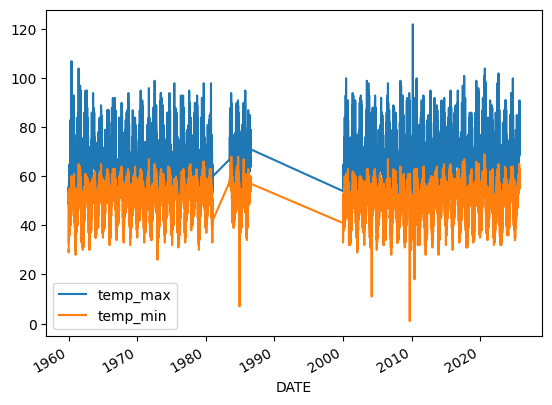

In [43]:
core_weather[['temp_max', 'temp_min']].plot()

In [48]:
core_weather.index.year.value_counts().sort_index()

DATE
1960    366
1961    365
1962    365
1963    365
1964    366
1965    365
1966    365
1967    365
1968    366
1969    365
1970    365
1971    365
1972    366
1973    365
1974    365
1975    365
1976    366
1977    365
1978    365
1979    365
1980    366
1983    184
1984    366
1985    365
1986    212
2000    365
2001    365
2002    365
2003    365
2004    366
2005    365
2006    365
2007    365
2008    366
2009    365
2010    365
2011    365
2012    365
2013    365
2014    365
2015    365
2016    366
2017    365
2018    365
2019    365
2020    366
2021    365
2022    365
2023    365
2024    366
2025    271
Name: count, dtype: int64

<Axes: xlabel='DATE'>

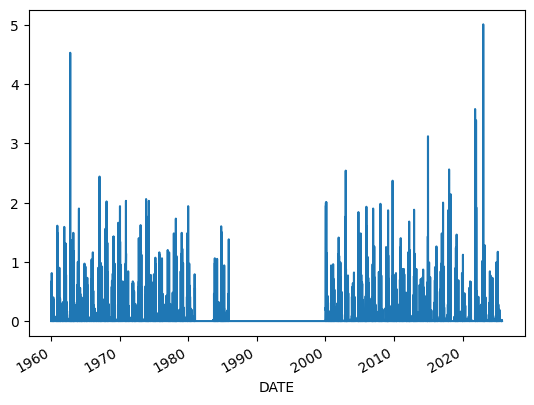

In [49]:
core_weather['precip'].plot()

In [54]:
core_weather.groupby(core_weather.index.year).sum()['precip']

DATE
1960    14.01
1961    13.87
1962    22.47
1963    19.11
1964    16.83
1965    16.32
1966    13.11
1967    23.98
1968    17.19
1969    25.70
1970    25.31
1971    10.61
1972    16.27
1973    29.37
1974    16.87
1975    17.54
1976     8.64
1977    11.70
1978    22.57
1979    23.79
1980    13.58
1983     7.13
1984    16.03
1985     8.50
1986     0.00
2000    21.09
2001    22.84
2002    19.12
2003    11.37
2004    12.97
2005    27.37
2006    22.79
2007    12.79
2008    13.86
2009    14.57
2010    22.67
2011    16.06
2012    22.93
2013     4.89
2014    19.62
2015     8.58
2016    19.77
2017    23.34
2018    16.82
2019    20.00
2020     6.42
2021    20.82
2022    15.38
2023    20.98
2024    17.15
2025     4.55
Name: precip, dtype: float64

In [55]:
core_weather['target'] = core_weather.shift(-1)['temp_max']

In [56]:
core_weather

,precip,temp_max,temp_min,target
DATE,,,,
1960-01-01,0.00,49.0,30.0,49.0
1960-01-02,0.00,49.0,29.0,54.0
1960-01-03,0.00,54.0,35.0,54.0
1960-01-04,0.00,54.0,36.0,55.0
1960-01-05,0.00,55.0,33.0,53.0
...,...,...,...,...
2025-09-24,0.00,78.0,63.0,72.0
2025-09-25,0.01,72.0,59.0,75.0
2025-09-26,0.00,75.0,57.0,72.0


In [57]:
core_weather = core_weather.iloc[:-1,:].copy()

In [58]:
core_weather

,precip,temp_max,temp_min,target
DATE,,,,
1960-01-01,0.00,49.0,30.0,49.0
1960-01-02,0.00,49.0,29.0,54.0
1960-01-03,0.00,54.0,35.0,54.0
1960-01-04,0.00,54.0,36.0,55.0
1960-01-05,0.00,55.0,33.0,53.0
...,...,...,...,...
2025-09-23,0.00,91.0,56.0,78.0
2025-09-24,0.00,78.0,63.0,72.0
2025-09-25,0.01,72.0,59.0,75.0


In [ ]:
# Ridge regression minimizes overfitting
from sklearn.linear_model import Ridge